In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix,classification_report, roc_curve, auc

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

def evaluate_model(y_true, y_pred, model_name):
    """Calculate metrics and returns dictionary"""
    acc= accuracy_score(y_true, y_pred)
    prec= precision_score(y_true, y_pred)
    rec= recall_score(y_true, y_pred)
    f1= f1_score(y_true, y_pred)

    print(f"{'='*50}\n {model_name} Results\n{'='*50}")
    print(f" Accuracy: {acc: .4f}\n Precision: {prec:.4f}\nRecall: {rec:.4f}\nF1 Score: {f1:.4f}")
    print(f"{'='*50}\n")

    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Draw a heatmap grid showing the exact false positives/negatives"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual True")
    plt.xlabel("Algorithm Prediction")
    plt.show()

In [2]:
df= pd.read_csv("data/titanic_clean.csv")

df.head(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S,Sex_male
0,0,3,22.0,1,0,7.2500,2,False,True,True
1,1,1,38.0,1,0,71.2833,2,False,False,False


In [3]:
y=df["Survived"]
X= df.drop(columns=["Survived"])

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42, stratify=y)

In [4]:
scaler= StandardScaler()

X_train_scaled=pd.DataFrame(scaler.fit_transform(X_train), columns= X_train.columns, index=X_train.index)
X_test_scaled= pd.DataFrame(scaler.transform(X_test), columns= X_test.columns, index=X_test.index)


In [5]:
print(f"Total engineered features per passenger: {X.shape[1]}")
print(f"Training Matrix Shape: {X_train_scaled.shape}")
print(f"Testing Matrix Shape: {X_test_scaled.shape}")

Total engineered features per passenger: 9
Training Matrix Shape: (712, 9)
Testing Matrix Shape: (179, 9)


 Logistic Regression Results
 Accuracy:  0.8045
 Precision: 0.7931
Recall: 0.6667
F1 Score: 0.7244



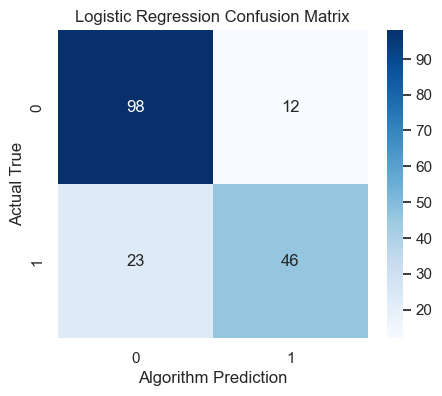

 Decision Tree Results
 Accuracy:  0.7598
 Precision: 0.7407
Recall: 0.5797
F1 Score: 0.6504



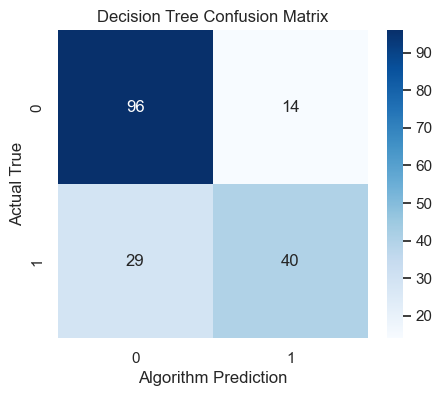

 Random Forest Results
 Accuracy:  0.7877
 Precision: 0.7818
Recall: 0.6232
F1 Score: 0.6935



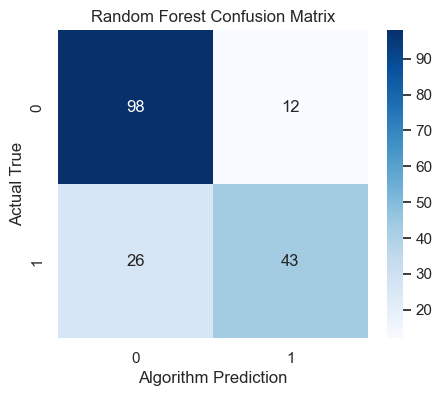

 KNN Results
 Accuracy:  0.8101
 Precision: 0.7612
Recall: 0.7391
F1 Score: 0.7500



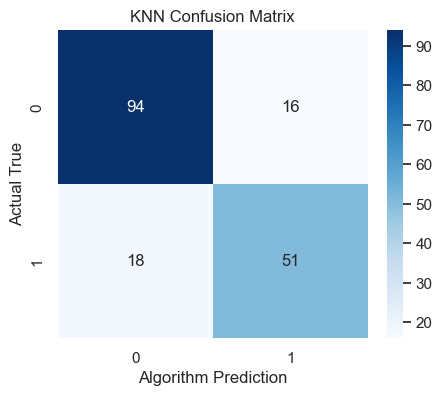

 SVM Results
 Accuracy:  0.8156
 Precision: 0.8333
Recall: 0.6522
F1 Score: 0.7317



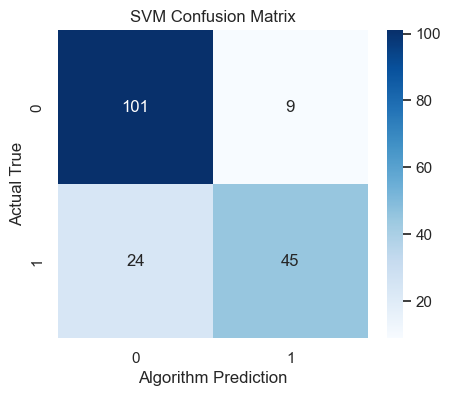

 Gradient Boosting Results
 Accuracy:  0.8156
 Precision: 0.8214
Recall: 0.6667
F1 Score: 0.7360



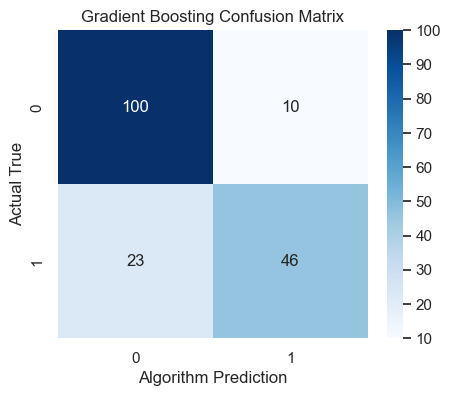

 Naive Bayes Results
 Accuracy:  0.7765
 Precision: 0.7164
Recall: 0.6957
F1 Score: 0.7059



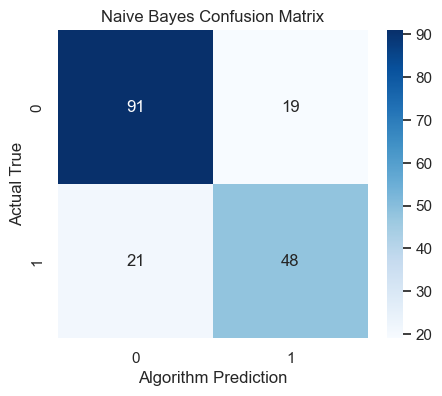


Final Leaderboard by F1-Score


,Model,Accuracy,Precision,Recall,F1
3,KNN,0.810056,0.761194,0.739130,0.750000
5,Gradient Boosting,0.815642,0.821429,0.666667,0.736000
4,SVM,0.815642,0.833333,0.652174,0.731707
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
6,Naive Bayes,0.776536,0.716418,0.695652,0.705882
2,Random Forest,0.787709,0.781818,0.623188,0.693548
1,Decision Tree,0.759777,0.740741,0.579710,0.650407


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

results= []
trained_models= {}

models={
    "Logistic Regression": LogisticRegression(random_state= 42, max_iter= 1000),
    "Decision Tree": DecisionTreeClassifier(random_state= 42,max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state= 42,max_depth=7),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf",probability=True,random_state= 42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state= 42),
    "Naive Bayes": GaussianNB(),
}

for name, model in models.items():
    if name in["Decision Tree", "Random Forest", "Gradient Boosting"]:
        train_features= X_train
        test_features= X_test
    else:
        train_features= X_train_scaled
        test_features= X_test_scaled

    model.fit(train_features, y_train)
    trained_models[name] = model

    y_pred= model.predict(test_features)

    metrics= evaluate_model(y_test, y_pred, name)
    results.append(metrics)

    plot_confusion_matrix(y_test, y_pred, name)

print("\n"+"="*50)
print("Final Leaderboard by F1-Score")
print("="*50)

comparison_df= pd.DataFrame(results).sort_values(by="F1", ascending=False)
display(comparison_df)

5-Fold Cross-Validation Results
Logistic Regression       | Mean: 0.8020 (+/- 0.0213)
Decision Tree             | Mean: 0.8063 (+/- 0.0294)
Random Forest             | Mean: 0.8217 (+/- 0.0297)
KNN                       | Mean: 0.8105 (+/- 0.0285)
SVM                       | Mean: 0.8245 (+/- 0.0096)
Gradient Boosting         | Mean: 0.8203 (+/- 0.0295)
Naive Bayes               | Mean: 0.7768 (+/- 0.0406)


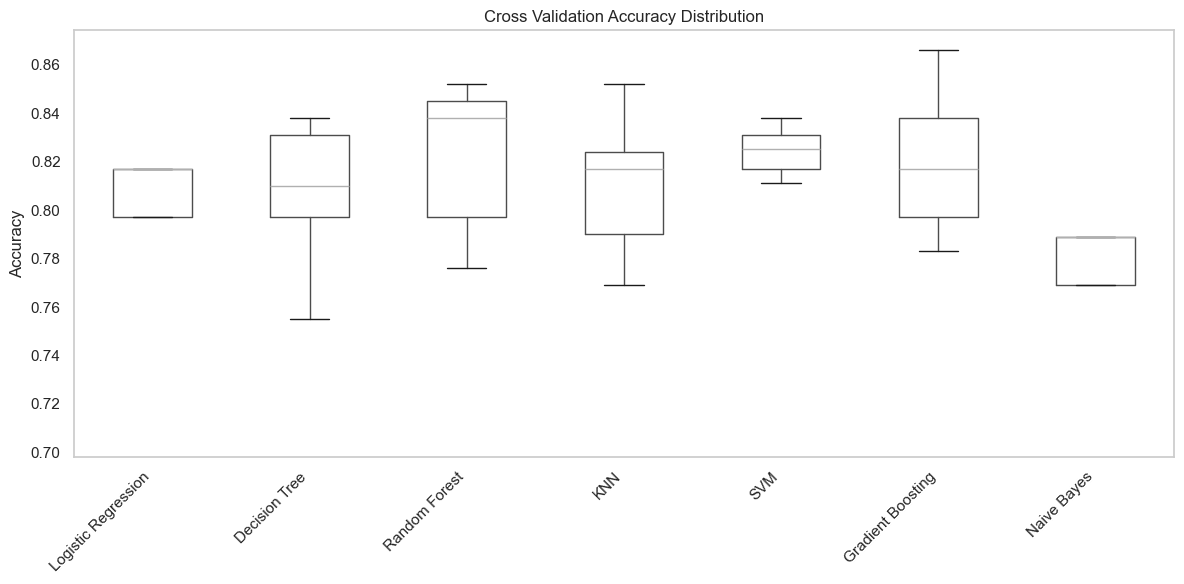

In [7]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation Results")
print("="*50)



cv_results= {}

for name, model in models.items():
    if name in["Decision Tree", "Random Forest", "Gradient Boosting"]:
        features= X_train
    else:
        features= X_train_scaled

    scores= cross_val_score(model,features,y_train, cv=5, scoring="accuracy")
    cv_results[name] = scores

    print(f"{name:25s} | Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

fig, ax= plt.subplots(figsize=(12,6))
cv_df= pd.DataFrame(cv_results)

cv_df.boxplot(ax=ax, grid=False)
ax.set_title("Cross Validation Accuracy Distribution")
ax.set_ylabel("Accuracy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV

print("Initializing RF Simulation Grid")

param_grid= {
    "n_estimators": [50,100,200],
    "max_depth": [3,5,7,10],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
}

grid_search=GridSearchCV(
    estimator= RandomForestClassifier(random_state= 42),
    param_grid= param_grid,
    cv=5,
    scoring= "f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n"+"="*50)
print("RF Simulation Complete: Optimal Architecture Found")
print("="*50)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Highest CV F1-Score: {grid_search.best_score_:.2f}")

best_rf= grid_search.best_estimator_


Initializing RF Simulation Grid
Fitting 5 folds for each of 108 candidates, totalling 540 fits

RF Simulation Complete: Optimal Architecture Found
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Highest CV F1-Score: 0.77


 Tuned Random Forest Results
 Accuracy:  0.8101
 Precision: 0.8070
Recall: 0.6667
F1 Score: 0.7302



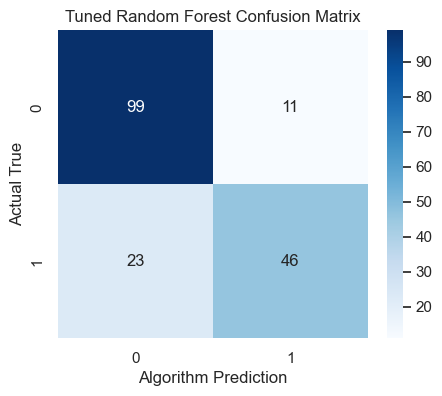

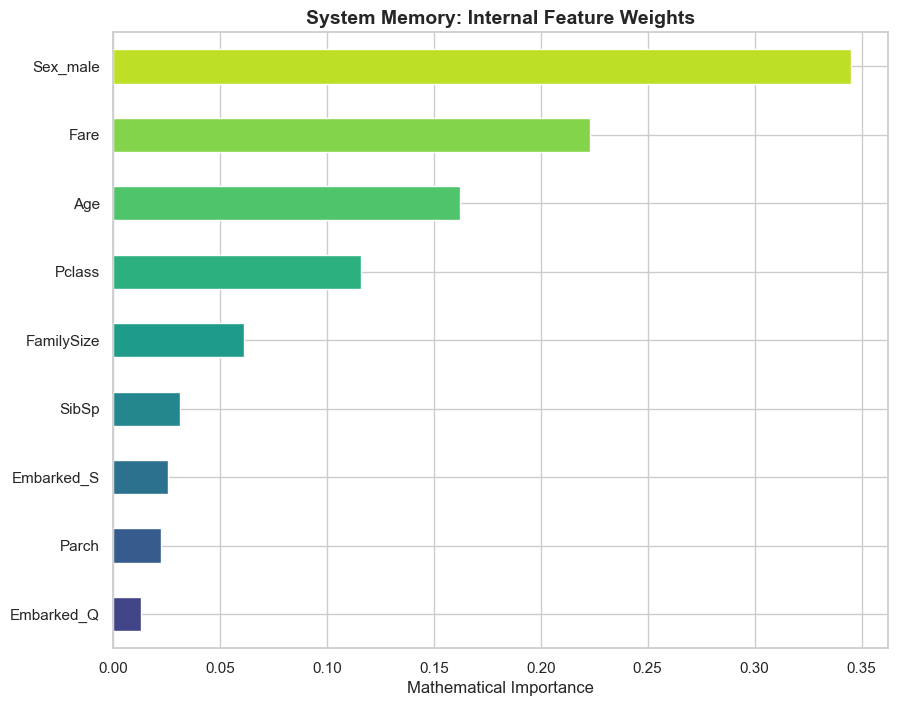

Top 5 critical Suvival Factors
FamilySize    0.061095
Pclass        0.115843
Age           0.162254
Fare          0.223239
Sex_male      0.345160
dtype: float64


In [13]:
y_pred_rf_tuned= best_rf.predict(X_test)
metrics_rf_tuned= evaluate_model(y_test, y_pred_rf_tuned, "Tuned Random Forest")
plot_confusion_matrix(y_test, y_pred_rf_tuned, "Tuned Random Forest")

feature_imp_rf= pd.Series(best_rf.feature_importances_, index=X_train.columns)

feature_imp_rf=feature_imp_rf.sort_values(ascending=True)

fig, ax= plt.subplots(figsize=(10,8))
colors= plt.cm.viridis(np.linspace(0.2,0.9, len(feature_imp_rf)))
feature_imp_rf.plot(kind="barh", ax=ax, color=colors)

ax.set_title("System Memory: Internal Feature Weights", fontsize=14, fontweight="bold")
ax.set_xlabel("Mathematical Importance")
plt.tight_layout
plt.show()

print("="*50)
print("Top 5 critical Suvival Factors")
print("="*50)
print(feature_imp_rf.tail(5))

Initializing SVM Simulation Grid
Fitting 5 folds for each of 16 candidates, totalling 80 fits

SVM Simulation Complete: Optimal Architecture Found
Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Highest CV F1-Score: 0.75
 Tuned SVM Results
 Accuracy:  0.8156
 Precision: 0.8214
Recall: 0.6667
F1 Score: 0.7360



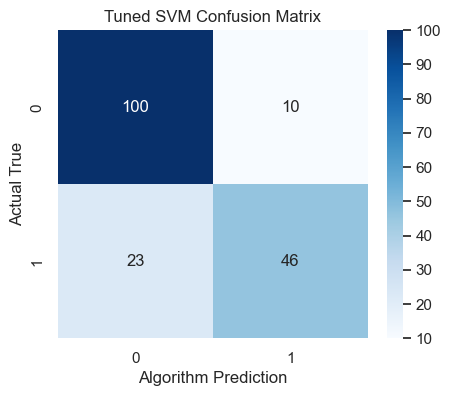

In [14]:
print("Initializing SVM Simulation Grid")

svm_param_grid={
    "C": [0.1,1,10,100],
    "gamma": [1,0.1,0.01,0.001],
    "kernel":["rbf"]
}

svm_grid_search= GridSearchCV(
    estimator= SVC(probability= True,random_state= 42),
    param_grid= svm_param_grid,
    cv= 5,
    scoring= "f1",
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train_scaled, y_train)
print("\n"+"="*50)
print("SVM Simulation Complete: Optimal Architecture Found")
print("="*50)
print(f"Best Parameters: {svm_grid_search.best_params_}")
print(f"Highest CV F1-Score: {svm_grid_search.best_score_:.2f}")

best_svm= svm_grid_search.best_estimator_

y_pred_svm_tuned= best_svm.predict(X_test_scaled)
metrics_svm_tuned= evaluate_model(y_test, y_pred_svm_tuned, "Tuned SVM")
plot_confusion_matrix(y_test, y_pred_svm_tuned, "Tuned SVM")

In [15]:
custom_passenger= pd.DataFrame(columns=X_train.columns)
custom_passenger.loc[0]=0

custom_passenger["Pclass"] = 1
custom_passenger["Sex_male"] = 0
custom_passenger["Age"] = 25
custom_passenger["Fare"] = 85.0
custom_passenger["SibSp"] = 0
custom_passenger["Parch"] = 0
custom_passenger["FamilySize"] = 1

if "Embarked_S" in custom_passenger.columns:
    custom_passenger["Embarked_S"] = 1

custom_passenger_scaled= pd.DataFrame(
    scaler.transform(custom_passenger),
    columns=custom_passenger.columns,
)

prediction_svm= best_svm.predict(custom_passenger_scaled)
prob_svm= best_svm.predict_proba(custom_passenger_scaled)[0]

prediction_rf= best_rf.predict(custom_passenger)
prob_rf= best_rf.predict_proba(custom_passenger)[0]

print("="*60)
print("Custom Passenger Simulation: Dual Engine A/B Test")
print("="*60)

print(f"----Engine A: Tuned SVM---")
if prediction_svm[0]==1:
    print(f"Outcome: SURVIVED! (Confidence {prob_svm[1]:.2%})\n")
else:
    print(f"Outcome: CASUALTY (Confidence {prob_svm[0]:.2%})\n")

print(f"----Engine B: Tuned Random Forest---")
if prediction_rf[0] == 1:
    print(f"Outcome: SURVIVED! (Confidence {prob_rf[1]:.2%})\n")
else:
    print(f"Outcome: CASUALTY (Confidence {prob_rf[0]:.2%})\n")


Custom Passenger Simulation: Dual Engine A/B Test
----Engine A: Tuned SVM---
Outcome: SURVIVED! (Confidence 93.86%)

----Engine B: Tuned Random Forest---
Outcome: SURVIVED! (Confidence 94.51%)

